In [94]:
import os
from typing import List, Union

file_dir = "~/ehrensberger/master-thesis/imports/mimicgen/datasets/robot"
file_dir = os.path.expanduser(file_dir)

robots: Union[str, List[str]] = "panda"
tasks: Union[str, List[str]] = "square"

n_frames = 9
horizon = 3

In [95]:
from random import randint

if isinstance(robots, str): 
    robots = [robots]

if isinstance(tasks, str): 
    tasks = [tasks]

files = [file for file in os.listdir(file_dir) if all(robot in file for robot in robots) and all(task in file for task in tasks)]

f_idx = randint(a=0, b=1) # for simplicity reasons only one file is selected for visualization 
file = files[f_idx] 

file

'square_d1_panda.hdf5'

In [116]:
import h5py 

frames = None
with h5py.File(os.path.join(file_dir, file), "r") as hf: 
    data = hf["data"]
    n_demos = len(data.keys())
    d_idx = randint(a=0, b=n_demos-1)
    demo = "demo_{:d}".format(d_idx)
    
    frames = data[demo]["obs"]["robot0_eye_in_hand_image"]
    obs_idx = randint(a=0, b=frames.shape[0]-n_frames)
    frames = frames[()][obs_idx:obs_idx+n_frames, ...]
    
frames.shape

(9, 84, 84, 3)

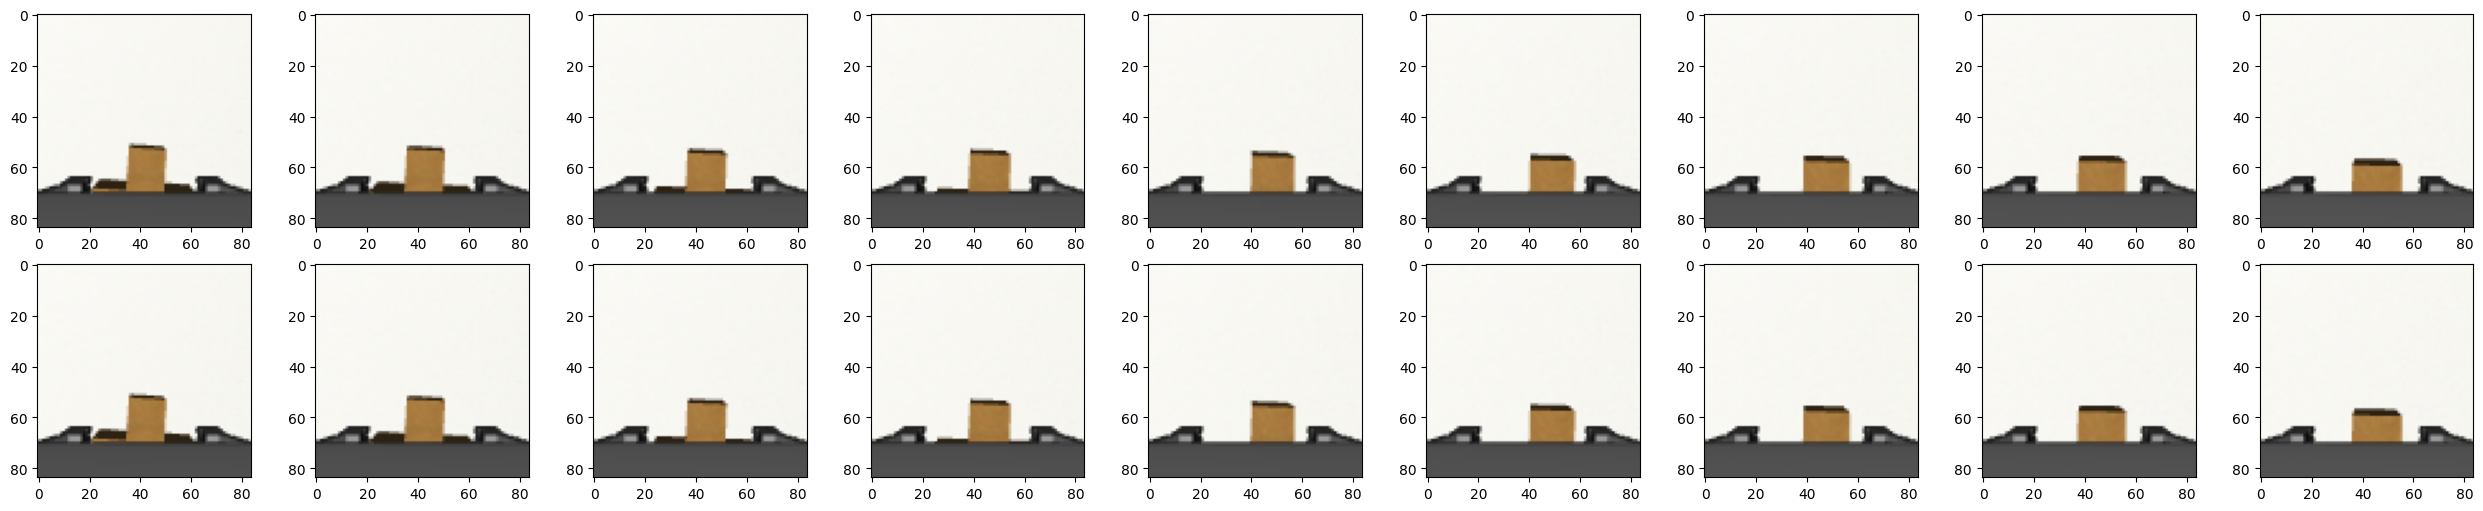

In [128]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(ncols=n_frames, nrows=2, figsize=(25, 5), constrained_layout=True)

for i in range(2): 
    for j, frame in enumerate(frames):
        ax[i, j].imshow(frame)
        
plt.show()